# Part 2 — Edge Processing Service: features, detection & throughput

This notebook drives the **streaming edge processor** (`fibersail_edge.EdgeProcessor`)
over the synthetic sensor and shows it doing its job:

- a **bounded rolling window** (a ring buffer) feeding **rolling features** — RMS,
  mean/std, and the **dominant frequency** (FFT peak) — computed **causally** (no
  look-ahead),
- a **self-calibrating anomaly detector** flagging the injected fault, scored with
  an **honest precision/recall** breakdown against the ground-truth window,
- **≥1000 samples/s** single-core throughput with comfortable headroom.

**What to look for**
1. Rolling features over time, with the ground-truth fault window shaded
2. A spectrogram — the resonance visibly slides during the fault
3. Detection overlay + the honest precision/recall report
4. Throughput benchmark (single core)
5. The provided CSV replayed through the *same* processor


In [1]:
import sys, itertools, time
from pathlib import Path

# Locate the repo root (holds pyproject.toml) so imports work from notebooks/ or root.
root = Path.cwd()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent
sys.path.insert(0, str(root / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
%matplotlib inline

from fibersail_edge import (
    DampedOscillatorSensor, SensorConfig, FaultConfig, CsvReplaySource,
    EdgeProcessor, ProcessorConfig, DetectorConfig, evaluate,
)
from fibersail_edge.benchmark import bench_processor_isolated, bench_end_to_end, make_samples

# Consistent, colorblind-safe styling (matches Part 1; data-viz reference palette).
BLUE, ORANGE, CRIT = "#2a78d6", "#eb6834", "#d03b3b"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110, "figure.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "legend.frameon": False,
})
CSV_PATH = root / "take_home_exercise" / "sample_dataset_small.csv"
print("repo root:", root)

repo root: /home/tiago-portela/Projects/Fibersail


## 1. Generate a faulted stream and run the processor

A 15 s run at 1 kHz with a bearing-wear-style fault at 7–10 s (natural frequency
50 → 35 Hz, damping cut to 40%). The processor uses a 1.5 s rolling window and a
0.1 s hop, so it emits **10 feature frames per second** — the same 10 Hz stream
Part 3 will upload. Nothing is emitted until the window first fills (~1.5 s).

In [2]:
FS, FN, FACTOR = 1000.0, 50.0, 0.7
sensor_cfg = SensorConfig(
    sample_rate_hz=FS, natural_freq_hz=FN, zeta=0.05, channel="acceleration",
    duration_s=15.0, seed=42,
    fault=FaultConfig(start_s=7.0, duration_s=3.0, omega_n_factor=FACTOR, zeta_factor=0.4),
)
proc_cfg = ProcessorConfig(sample_rate_hz=FS, window_s=1.5, hop_s=0.1)

# Materialize the raw signal once (for plotting only).
raw = np.array([(s.t, s.value) for s in DampedOscillatorSensor(sensor_cfg).stream()])
t_raw, x_raw = raw[:, 0], raw[:, 1]
f0, f1 = DampedOscillatorSensor(sensor_cfg).fault_window

# Run the processor on a fresh (identical) stream and collect the feature frames.
proc = EdgeProcessor(proc_cfg)
frames = list(proc.process_stream(DampedOscillatorSensor(sensor_cfg)))
tf   = np.array([f.t for f in frames])
rms  = np.array([f.rms for f in frames])
freq = np.array([f.dominant_freq_hz for f in frames])
flag = np.array([f.is_anomaly for f in frames])
score = np.array([f.score for f in frames])

print(f"{len(x_raw):,} raw samples @ {FS:.0f} Hz -> {len(frames)} frames @ {proc.feature_rate_hz:.0f} Hz")
print(f"ground-truth fault window = [{f0:.1f}, {f1:.1f}] s   (50 Hz -> {FN*FACTOR:.0f} Hz)")
print(f"frames flagged anomalous: {int(flag.sum())} / {len(frames)}")

15,000 raw samples @ 1000 Hz -> 136 frames @ 10 Hz
ground-truth fault window = [7.0, 10.0] s   (50 Hz -> 35 Hz)
frames flagged anomalous: 34 / 136


## 2. Rolling features over time (causal, no look-ahead)

The **dominant frequency** is the primary fault signature — it drops from ~50 Hz
to ~35 Hz inside the window — and the **RMS** rises because the fault also reduces
damping. Detector-flagged frames are marked in red. Note the causal lag: features
respond only once the trailing window fills with faulty data, and they linger
briefly after the fault ends (the honest evaluation below accounts for this).

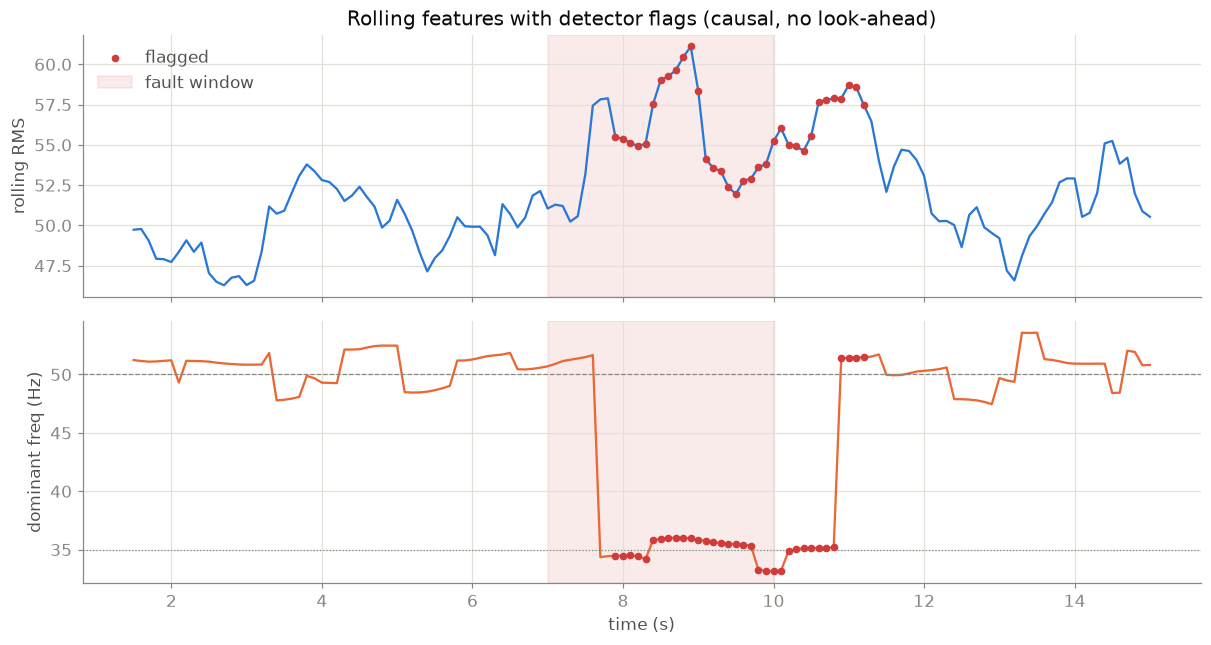

In [3]:
fig, (axr, axf) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axr.plot(tf, rms, color=BLUE, lw=1.5)
axr.scatter(tf[flag], rms[flag], color=CRIT, s=16, zorder=3, label="flagged")
axr.axvspan(f0, f1, color=CRIT, alpha=0.10, label="fault window")
axr.set(ylabel="rolling RMS", title="Rolling features with detector flags (causal, no look-ahead)")
axr.legend(loc="upper left")

axf.plot(tf, freq, color=ORANGE, lw=1.5)
axf.scatter(tf[flag], freq[flag], color=CRIT, s=16, zorder=3)
axf.axhline(FN, color=MUTED, lw=0.8, ls="--")
axf.axhline(FN * FACTOR, color=MUTED, lw=0.8, ls=":")
axf.axvspan(f0, f1, color=CRIT, alpha=0.10)
axf.set(xlabel="time (s)", ylabel="dominant freq (Hz)")
plt.tight_layout(); plt.show()

## 3. Spectrogram — the resonance slides during the fault

An STFT of the raw signal. The bright ridge sits at ~50 Hz, then drops to ~35 Hz
across the shaded fault window before returning — exactly what the dominant-freq
feature tracks with one number per frame.

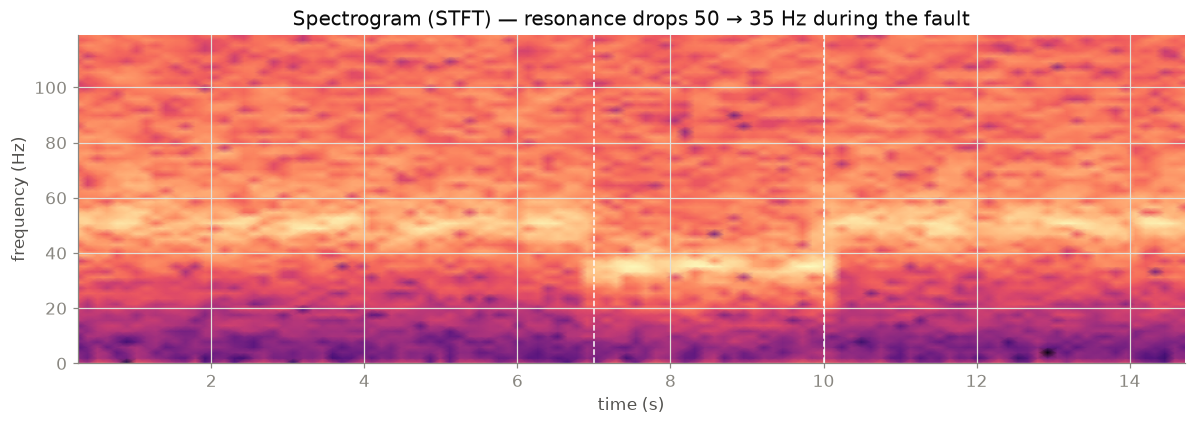

In [4]:
f_sxx, t_sxx, Sxx = spectrogram(x_raw, fs=FS, nperseg=512, noverlap=384)
band = f_sxx <= 120  # focus on the interesting low band
fig, ax = plt.subplots(figsize=(11, 4))
ax.pcolormesh(t_sxx, f_sxx[band], 10 * np.log10(Sxx[band] + 1e-12), shading="gouraud", cmap="magma")
ax.axvline(f0, color="white", lw=1.0, ls="--")
ax.axvline(f1, color="white", lw=1.0, ls="--")
ax.set(xlabel="time (s)", ylabel="frequency (Hz)", title="Spectrogram (STFT) — resonance drops 50 → 35 Hz during the fault")
plt.tight_layout(); plt.show()

## 4. Detection overlay + honest precision/recall

`evaluate()` scores the detector against the ground-truth window in a single
streaming pass and reports **four complementary views**. The **raw** (point-label)
numbers are a pessimistic floor: frames right after the fault onset are labeled
faulty before a causal window can possibly see the change, and frames right after
the fault ends still show it. The **windowed** view relabels a frame faulty only
when its trailing window is *majority* faulty — a first-principles guard band of
`window_s / 2`, reported transparently, not tuned.

In [5]:
report = evaluate(DampedOscillatorSensor(sensor_cfg), EdgeProcessor(proc_cfg))
print(report.format_summary())

Edge processing — detection evaluation
  detector       : BaselineZScoreDetector
  window         : 1.50 s   guard band: 0.75 s
  frame rate     : 10.0 Hz
  fault window   : 7.00–10.00 s
  frames scored  : 136
  event detected : YES
  detect latency : 0.90 s (reference ≈ 1.05 s)

  raw (point labels — pessimistic floor):
    TP=22    FP=12    FN=8     TN=94   
    precision= 0.647  recall= 0.733  F1= 0.688  FPR= 0.113

  windowed (majority-faulty, ±0.75 s guard):
    TP=29    FP=5     FN=1     TN=101  
    precision= 0.853  recall= 0.967  F1= 0.906  FPR= 0.047


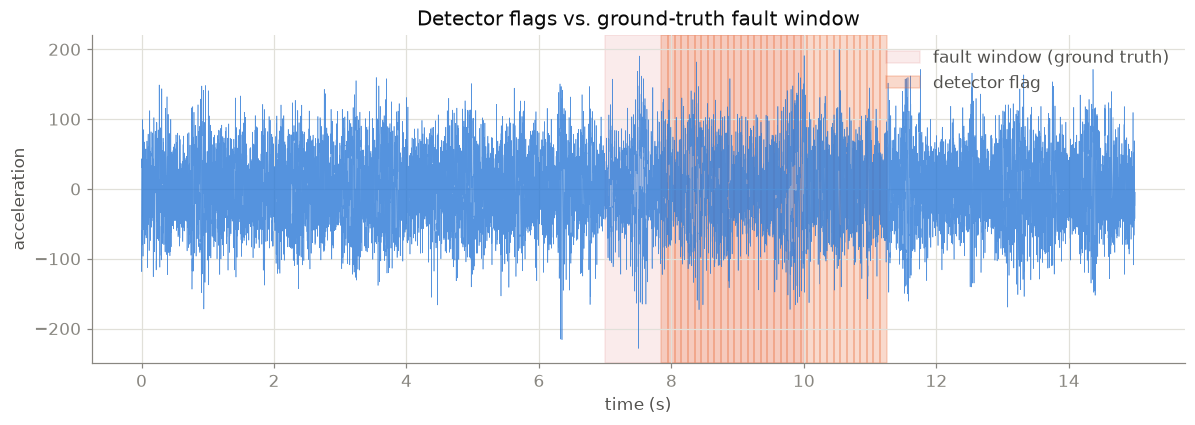

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_raw, x_raw, color=BLUE, lw=0.4, alpha=0.8)
ax.axvspan(f0, f1, color=CRIT, alpha=0.10, label="fault window (ground truth)")
# Shade the spans the detector flagged.
first = True
for ti, fi in zip(tf, flag):
    if fi:
        ax.axvspan(ti - proc_cfg.hop_s / 2, ti + proc_cfg.hop_s / 2, color=ORANGE, alpha=0.25,
                   label="detector flag" if first else None)
        first = False
ax.set(xlabel="time (s)", ylabel="acceleration", title="Detector flags vs. ground-truth fault window")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 5. Throughput (single core)

The per-sample path is just a ring-buffer push; the FFT runs only ~10×/s. So the
processor sustains far more than the required 1000 samples/s. *Isolated* times only
the processing loop over pre-generated samples; *end-to-end* includes the sensor's
RK4 integration.

In [7]:
samples = make_samples(120_000, SensorConfig(sample_rate_hz=FS, seed=42))
iso = bench_processor_isolated(samples, proc_cfg)
e2e = bench_end_to_end(DampedOscillatorSensor(SensorConfig(sample_rate_hz=FS, seed=42)), 120_000, proc_cfg)
print(f"isolated  : {iso['samples_per_s']:>12,.0f} samp/s   {iso['x_realtime']:>6.0f}x real-time   {iso['per_sample_us']:.2f} us/sample")
print(f"end-to-end: {e2e['samples_per_s']:>12,.0f} samp/s   {e2e['x_realtime']:>6.0f}x real-time")
print(f"\ntarget >= 1,000 samp/s: {'PASS' if iso['samples_per_s'] >= 1000 else 'FAIL'} "
      f"({iso['samples_per_s']/1000:,.0f}x headroom)")

isolated  :      416,967 samp/s      417x real-time   2.40 us/sample
end-to-end:      137,063 samp/s      137x real-time

target >= 1,000 samp/s: PASS (417x headroom)


## 6. The provided dataset through the *same* processor

The processor is source-agnostic: point it at the recorded CSV (~91 Hz strain, no
injected fault) via `EdgeProcessor.for_source`, which reads the source's sample
rate and sizes the window automatically. Detrending keeps the ~1500 DC strain
offset from hijacking the FFT peak.

CSV: 187 frames @ 10.1 Hz (window 136 samples @ 91 Hz)


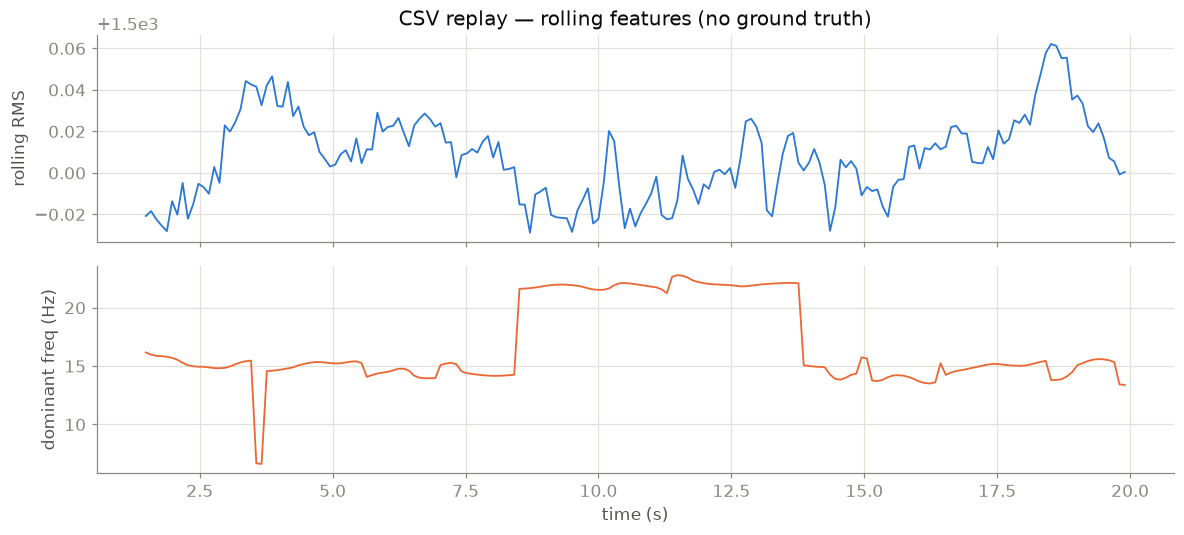

In [8]:
csv_proc = EdgeProcessor.for_source(CsvReplaySource(str(CSV_PATH)))
csv_frames = list(csv_proc.process_stream(CsvReplaySource(str(CSV_PATH))))
ctf   = np.array([f.t for f in csv_frames])
crms  = np.array([f.rms for f in csv_frames])
cfreq = np.array([f.dominant_freq_hz for f in csv_frames])
print(f"CSV: {len(csv_frames)} frames @ {csv_proc.feature_rate_hz:.1f} Hz "
      f"(window {csv_proc.config.window_samples} samples @ {csv_proc.config.sample_rate_hz:.0f} Hz)")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a1.plot(ctf, crms, color=BLUE, lw=1.2); a1.set(ylabel="rolling RMS", title="CSV replay — rolling features (no ground truth)")
a2.plot(ctf, cfreq, color=ORANGE, lw=1.2); a2.set(xlabel="time (s)", ylabel="dominant freq (Hz)")
plt.tight_layout(); plt.show()

## Notes & assumptions

- **Causal window, reported honestly.** Features use only the trailing
  `window_s`, so detection lags the true onset and lingers after the offset. The
  evaluation reports raw *and* windowed metrics plus detection latency rather than
  hiding the boundary effect.
- **Detector is self-calibrating and untuned.** It learns a healthy baseline over
  the first ~3 s, then flags deviations beyond `k=4σ` on dominant frequency or
  RMS, with a debounce. `k` is chosen a priori; the false-positive rate is checked
  empirically on a healthy stream (see `tests/test_detector.py`).
- **Bounded memory.** The ring buffer and detector hold a fixed number of scalars
  regardless of stream length (< 100 KB total) — see the README footprint section.
- **Decimation.** The 10 Hz frame stream carries the newest raw sample (point
  decimation, not anti-aliased) as coarse telemetry for Part 3; spectral content
  is already summarized by `dominant_freq_hz`.
